In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [7]:
df.shape

(19158, 13)

In [6]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [7]:
# df.isnull().mean()
df.isnull().mean()*100  #-->this is in percentage to know how many missing data in each column

#to apply cca(complete case analysis) approach:
#MCAR-->missing completely at random
#5% or <less that5% missing data is acceptable to apply cca approach

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [8]:
#here we will take under 5% column name

df1=df[["city_development_index","enrolled_university","education_level","experience","training_hours"]]

In [9]:
df1.head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0


In [10]:
df1=df1.dropna()

In [11]:
df.shape,df1.shape

((19158, 13), (17182, 5))

In [ ]:
#to check distribution with graph for numerical column-->used hist and kde

# two way of doing distribution

In [39]:
# fig,ax=plt.subplots(1,1,figsize=(5,5))
# plt.hist(df["city_development_index"],bins=20,density=True,color="red",alpha=0.5)
# plt.hist(df1["city_development_index"],bins=20,density=True,color="green",alpha=0.8)

# plt.show()


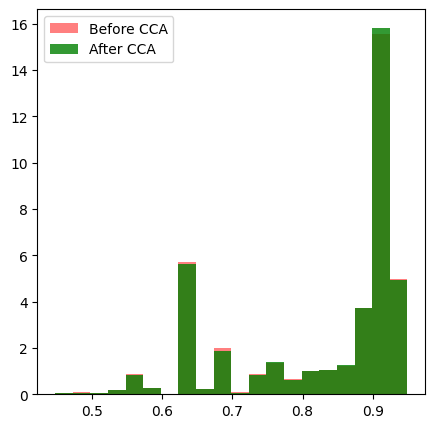

In [ ]:
#1 method to check distribution is hist and kde both in one graph
fig,ax = plt.subplots(1,1,figsize=(5,5))

plt.hist(
    df["city_development_index"],
    bins=20,
    density=True,
    color="red",
    alpha=0.5,
    label="Before CCA"
)

plt.hist(
    df1["city_development_index"],
    bins=20,
    density=True,
    color="green",
    alpha=0.8,
    label="After CCA"
)

plt.legend()
plt.show()

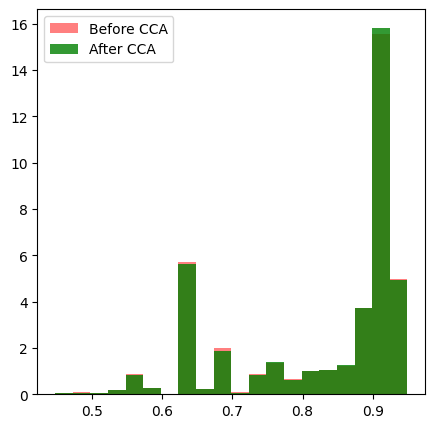

In [ ]:
#2 method to check distribution is hist and kde both in one graph

#city development index distribution
fig,ax = plt.subplots(figsize=(5,5))

ax.hist(
    df["city_development_index"],
    bins=20,
    density=True,
    color="red",
    alpha=0.5,
    label="Before CCA"
)

ax.hist(
    df1["city_development_index"],
    bins=20,
    density=True,
    color="green",
    alpha=0.8,
    label="After CCA"
)

ax.legend()
plt.show()

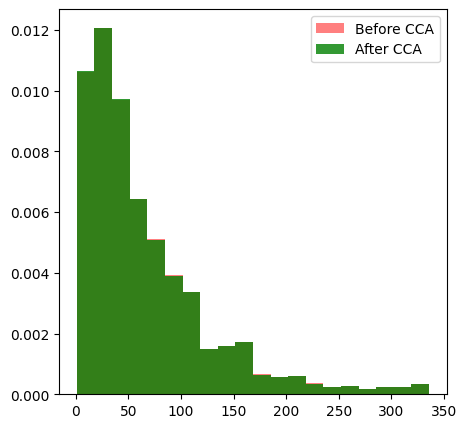

In [ ]:
#training hours distribution

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.hist(df["training_hours"],bins=20,density=True,color="red",alpha=0.5,label="Before CCA")
ax.hist(df1["training_hours"],bins=20,density=True,color="green",alpha=0.8,label="After CCA")
ax.legend()
plt.show()

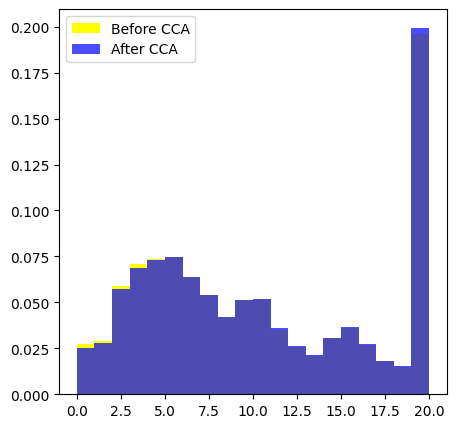

In [54]:
#experience distribution

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.hist(df["experience"],bins=20,density=True,color="yellow",label="Before CCA")
ax.hist(df1["experience"],bins=20,density=True,color="blue",alpha=0.7,label="After CCA")
ax.legend()
plt.show()

In [ ]:
#check the frequent of categorical data

In [24]:
temp=df["education_level"].value_counts(normalize=True)

In [26]:
temp

education_level
Graduate          0.620280
Masters           0.233234
High School       0.107872
Phd               0.022141
Primary School    0.016472
Name: proportion, dtype: float64

In [25]:
temp1=df1["education_level"].value_counts(normalize=True)

In [27]:
temp1

education_level
Graduate          0.619835
Masters           0.234082
High School       0.107380
Phd               0.022116
Primary School    0.016587
Name: proportion, dtype: float64

In [28]:
pd.concat([temp,temp1],axis=1)

,proportion,proportion
education_level,,
Graduate,0.620280,0.619835
Masters,0.233234,0.234082
High School,0.107872,0.107380
Phd,0.022141,0.022116
Primary School,0.016472,0.016587


In [19]:
temp=df["enrolled_university"].value_counts(normalize=True)

In [20]:
temp

enrolled_university
no_enrollment       0.736043
Full time course    0.200139
Part time course    0.063818
Name: proportion, dtype: float64

In [21]:
temp1=df1["enrolled_university"].value_counts(normalize=True)

In [22]:
temp1

enrolled_university
no_enrollment       0.735188
Full time course    0.200733
Part time course    0.064079
Name: proportion, dtype: float64

In [23]:
pd.concat([temp,temp1],axis=1)

,proportion,proportion
enrolled_university,,
no_enrollment,0.736043,0.735188
Full time course,0.200139,0.200733
Part time course,0.063818,0.064079
